# Defected Nuts

Solution Author: Cowille

You get 431 photos of good hazelnuts and 70 photos that each hide a defect somewhere, a crack or a cut or a hole or a smear of print. For every test photo you output a map that says, pixel by pixel, how anomalous it looks but you dont have any segmentation mask labels, so this task becomes unsuperivsed.

If you cannot learn what a defect looks like, then you need to learn what normal looks like very well, then flag whatever does not fit. the methods to do these just differ in 2 choices: how you describe normal, and how you measure does not fit. 

For each test image, we output a heatmap, and the metric is AUPRO with a 30% false-positive cap. Because AUPRO is region-weighted, spatial resolution matters a lot: a very small, thin defect can count as much as a large defect region, so if the heatmap smears or loses small defects, the score drops. We also do not need to focus much on threshold tuning, because AUPRO evaluates how well the heatmap ranks anomalous pixels rather than relying on one chosen threshold. Since the false-positive budget is fairly generous at 30%, most reasonable heatmaps already achieve a high score.

The solution uses a pretrained ResNet18 as a fixed feature extractor. For each image, we take hidden activations from the first three ResNet blocks, resize them to a 128×128 grid, and treat each grid position as a patch descriptor. From the normal training images, we build a random bank of patch descriptors instead of storing all of them, since keeping every patch would be too memory heavy. For each test patch, we compute its distance to the closest normal patch in the bank. Patches that are far from all normal patches receive high anomaly scores. The resulting 128×128 anomaly map is upsampled to the original image size, lightly smoothed, globally normalized, and saved as the submission.

This method is inspired by PatchCore. you can read more about it in the paper: https://arxiv.org/abs/2106.08265. 

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
import numpy as np
import pandas as pd

torch.manual_seed(2026)

device = torch.device("cuda")

model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT).to(device).eval()

C:\Users\Antony\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\triton\windows_utils.py:405: UserWarning: Failed to find CUDA.
  warnings.warn("Failed to find CUDA.")


In [2]:
from torch.utils.data import Dataset, DataLoader
from torchvision.io import read_image
from torchvision.transforms import v2 as T

class NutDataset(Dataset):
    def __init__(self, paths):
        self.paths = paths
        self.transform = T.Compose([
            T.ToDtype(torch.float32, scale=True),
            T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]) # imagenet mean/std
        ])
                
    def __len__(self): 
        return len(self.paths)

    def __getitem__(self, index):
        image = read_image(self.paths[index])
        image = self.transform(image)
        return image

In [3]:
@torch.inference_mode()
def get_features(images):
    images = images.to(device)
    
    x = nn.Sequential(*list(model.children())[:4])(images)

    l1 = model.layer1(x)
    l2 = model.layer2(l1)
    l3 = model.layer3(l2)

    features = []

    for l in [l1, l2, l3]:
        l = F.interpolate(l, size = (128,128), mode = "bilinear")
        l = l.flatten(start_dim=2)
        l = l.transpose(1,2)
        
        features.append(l)
        
    return torch.cat(features, dim=-1)      # [B, 16384, 448]

In [4]:
from pathlib import Path

train_paths = sorted(Path("data/train").glob("*.png"), key=lambda p: int(p.stem))
test_paths  = sorted(Path("data/test").glob("*.png"),  key=lambda p: int(p.stem))

bs = 32

train_loader = DataLoader(NutDataset(train_paths), batch_size = bs)
test_loader = DataLoader(NutDataset(test_paths), batch_size = bs)

In [5]:
ch = [64, 128, 256]
n_keep = 100000 # You can tune this value based on your memory.
frac = n_keep/ (len(train_paths)*128*128)
frac

0.01416128915313225

In [6]:
bank = []
for imgs in train_loader:
    f = get_features(imgs).reshape(-1, 448)
    idx = torch.randperm(len(f), device=device)[:round(len(f) * frac)]
    bank.append(f[idx])
    
bank = torch.cat(bank)
bank.shape

torch.Size([100005, 448])

In [7]:
maps = []

for imgs in test_loader:
    f = get_features(imgs)
    out = []
    for patches in f:
        d = torch.cat([torch.cdist(c, bank).min(1).values 
                       for c in patches.split(4096)]) # 4096 = (128*128)/4
        out.append(d.reshape(128,128))
    maps.append(torch.stack(out))

maps = torch.cat(maps)

In [8]:
maps = F.interpolate(maps[:, None], size=(1024, 1024), mode="bilinear")[:, 0].cpu().numpy()

In [9]:
from scipy.ndimage import gaussian_filter

maps = np.stack([gaussian_filter(m, sigma=2) for m in maps]) # This is not necessary, but it can slightly improve the score.

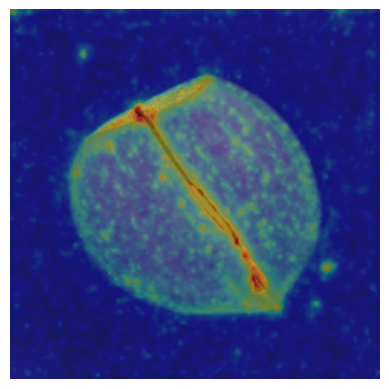

In [10]:
import matplotlib.pyplot as plt

i = 67

img = read_image(str(test_paths[i])).permute(1, 2, 0)

plt.imshow(img)
plt.imshow(maps[i], cmap="jet", alpha=0.4)
plt.axis("off")
plt.show()

In [11]:
maps = (maps - maps.min()) / (maps.max() - maps.min())
maps = (maps * 255).astype(np.uint8)

In [13]:
import base64

rows = [{"id": i, "data": base64.b85encode(m.tobytes()).decode("ascii")} for i, m in enumerate(maps)]
pd.DataFrame(rows).to_csv("submission.csv", index=False)

This solution achieves 0.9824 on the public leaderboard and 0.9661 on the private leaderboard. To improve it further, one simple next step would be whitening the patch features before computing distances. Also notice that this is not a fully unsupervised task its an weakly supervised task since we have the image level labels, this weak supervision could potentially be used in interesting ways to further improve the score.